<a href="https://colab.research.google.com/github/mariemshrief28-prog/Machine-Learning-projects/blob/main/Cereals_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
df=pd.read_csv('cereal.csv')
df.head()

,name,mfr,type,calories,protein,fat,sodium,fiber,carbo,sugars,potass,vitamins,shelf,weight,cups,rating
0,100% Bran,N,C,70,4,1,130,10.0,5.0,6,280,25,3,1.0,0.33,68.402973
1,100% Natural Bran,Q,C,120,3,5,15,2.0,8.0,8,135,0,3,1.0,1.00,33.983679
2,All-Bran,K,C,70,4,1,260,9.0,7.0,5,320,25,3,1.0,0.33,59.425505
3,All-Bran with Extra Fiber,K,C,50,4,0,140,14.0,8.0,0,330,25,3,1.0,0.50,93.704912
4,Almond Delight,R,C,110,2,2,200,1.0,14.0,8,-1,25,3,1.0,0.75,34.384843


In [ ]:
import sklearn
from sklearn.preprocessing import LabelEncoder

le=LabelEncoder()

df['mfr']=le.fit_transform(df['mfr']).astype(int)
df['name']=le.fit_transform(df['name']).astype(int)
df['type']=le.fit_transform(df['type']).astype(int)

In [ ]:
df.head()

,name,mfr,type,calories,protein,fat,sodium,fiber,carbo,sugars,potass,vitamins,shelf,weight,cups,rating
0,0,3,0,70,4,1,130,10.0,5.0,6,280,25,3,1.0,0.33,68.402973
1,1,5,0,120,3,5,15,2.0,8.0,8,135,0,3,1.0,1.00,33.983679
2,2,2,0,70,4,1,260,9.0,7.0,5,320,25,3,1.0,0.33,59.425505
3,3,2,0,50,4,0,140,14.0,8.0,0,330,25,3,1.0,0.50,93.704912
4,4,6,0,110,2,2,200,1.0,14.0,8,-1,25,3,1.0,0.75,34.384843


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77 entries, 0 to 76
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   name      77 non-null     int64  
 1   mfr       77 non-null     int64  
 2   type      77 non-null     int64  
 3   calories  77 non-null     int64  
 4   protein   77 non-null     int64  
 5   fat       77 non-null     int64  
 6   sodium    77 non-null     int64  
 7   fiber     77 non-null     float64
 8   carbo     77 non-null     float64
 9   sugars    77 non-null     int64  
 10  potass    77 non-null     int64  
 11  vitamins  77 non-null     int64  
 12  shelf     77 non-null     int64  
 13  weight    77 non-null     float64
 14  cups      77 non-null     float64
 15  rating    77 non-null     float64
dtypes: float64(5), int64(11)
memory usage: 9.8 KB


In [ ]:
for colms in df.columns:
  (df[colms]==0).sum()
  print({colms},(df[colms]==0).sum())
  df[colms]=df[colms].replace(0,df[colms].mean())

  print({colms},(df[colms]==0).sum())

{'name'} 1
{'name'} 0
{'mfr'} 1
{'mfr'} 0
{'type'} 74
{'type'} 0
{'calories'} 0
{'calories'} 0
{'protein'} 0
{'protein'} 0
{'fat'} 27
{'fat'} 0
{'sodium'} 9
{'sodium'} 0
{'fiber'} 19
{'fiber'} 0
{'carbo'} 0
{'carbo'} 0
{'sugars'} 7
{'sugars'} 0
{'potass'} 0
{'potass'} 0
{'vitamins'} 8
{'vitamins'} 0
{'shelf'} 0
{'shelf'} 0
{'weight'} 0
{'weight'} 0
{'cups'} 0
{'cups'} 0
{'rating'} 0
{'rating'} 0


In [ ]:
df.isnull().sum()

,0
name,0
mfr,0
type,0
calories,0
protein,0
fat,0
sodium,0
fiber,0
carbo,0
sugars,0


In [ ]:
df.corr()

,name,mfr,type,calories,protein,fat,sodium,fiber,carbo,sugars,potass,vitamins,shelf,weight,cups,rating
name,1.000000,-0.083368,0.013918,-0.002818,0.085068,-0.291716,0.018412,-0.118413,0.249618,-0.173700,-0.028051,0.250154,-0.115917,0.000976,0.102245,0.146645
mfr,-0.083368,1.000000,0.096909,-0.085081,0.045388,0.222857,-0.183800,0.021707,-0.057199,-0.112239,-0.003615,-0.205754,-0.001888,-0.248326,-0.051876,0.161645
type,0.013918,0.096909,1.000000,-0.071596,0.269265,-0.008575,-0.151582,-0.072101,-0.123023,-0.239984,-0.079825,-0.040380,-0.131730,-0.039880,0.060057,0.203024
calories,-0.002818,-0.085081,-0.071596,1.000000,0.019066,0.415027,0.038860,-0.333224,0.250681,0.358587,-0.066609,0.128429,0.097234,0.696091,0.087200,-0.689376
protein,0.085068,0.045388,0.269265,0.019066,1.000000,0.210977,-0.009441,0.348581,-0.130864,-0.374557,0.549407,0.035683,0.133865,0.216158,-0.244469,0.470618
fat,-0.291716,0.222857,-0.008575,0.415027,0.210977,1.000000,-0.296620,-0.048607,-0.249932,0.066955,0.140012,-0.142721,0.243337,0.098116,-0.134068,-0.247361
sodium,0.018412,-0.183800,-0.151582,0.038860,-0.009441,-0.296620,1.000000,-0.035794,0.417434,-0.353067,-0.059684,0.132599,-0.216464,0.096127,0.154070,-0.124401
fiber,-0.118413,0.021707,-0.072101,-0.333224,0.348581,-0.048607,-0.035794,1.000000,-0.336270,-0.025642,0.848107,-0.072736,0.246231,0.189118,-0.436810,0.509307
carbo,0.249618,-0.057199,-0.123023,0.250681,-0.130864,-0.249932,0.417434,-0.336270,1.000000,-0.354840,-0.349685,0.239638,-0.101790,0.135136,0.363932,0.052055
sugars,-0.173700,-0.112239,-0.239984,0.358587,-0.374557,0.066955,-0.353067,-0.025642,-0.354840,1.000000,0.050217,-0.099050,0.074324,0.302530,-0.027819,-0.539987


In [ ]:
x=df.drop(['rating'],axis=1)
x.head()

,name,mfr,type,calories,protein,fat,sodium,fiber,carbo,sugars,potass,vitamins,shelf,weight,cups
0,38,3.0,0.038961,70,4,1.000000,130.0,10.0,5.0,6.000000,280,25.000000,3,1.0,0.33
1,1,5.0,0.038961,120,3,5.000000,15.0,2.0,8.0,8.000000,135,28.246753,3,1.0,1.00
2,2,2.0,0.038961,70,4,1.000000,260.0,9.0,7.0,5.000000,320,25.000000,3,1.0,0.33
3,3,2.0,0.038961,50,4,1.012987,140.0,14.0,8.0,6.922078,330,25.000000,3,1.0,0.50
4,4,6.0,0.038961,110,2,2.000000,200.0,1.0,14.0,8.000000,-1,25.000000,3,1.0,0.75


In [ ]:
y=df['rating']

<Axes: >

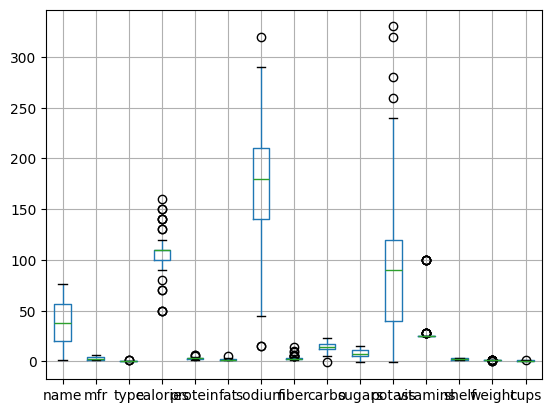

In [ ]:
x.boxplot()

In [ ]:
for colms in x.columns:
  q1=x[colms].quantile(0.25)
  q3=x[colms].quantile(0.75)

  iqr=q3-q1

  upper=q3+1.5*iqr
  lower=q1-1.5*iqr

  x[colms]=x[colms].loc[(x[colms]<upper)&(x[colms]>lower)]

<Axes: >

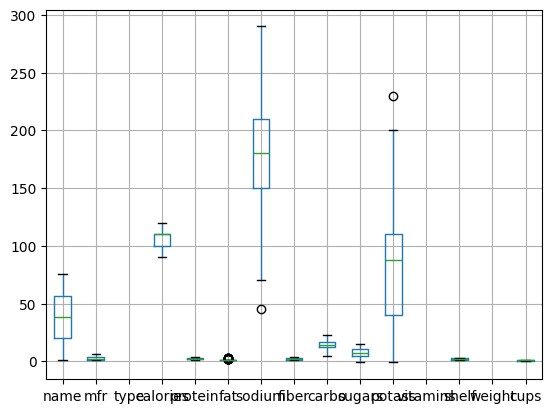

In [ ]:
x.boxplot()

In [ ]:
x=x.drop(['fat'],axis=1)

<Axes: >

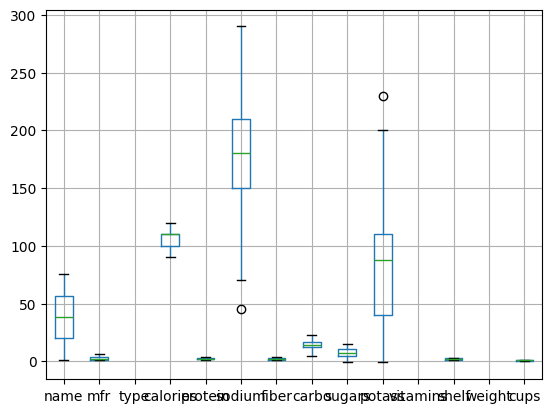

In [ ]:
x.boxplot()

In [ ]:
for colms in x.columns:
  x[colms]= (x[colms]-x[colms].mean())/x[colms].std()

In [ ]:
x.head()

,name,mfr,type,calories,protein,sodium,fiber,carbo,sugars,potass,vitamins,shelf,weight,cups
0,-0.022496,0.139562,NaN,NaN,1.743777,-0.961846,NaN,-2.508783,-0.401328,NaN,NaN,0.951573,NaN,-2.185716
1,-1.709107,1.315770,NaN,1.515354,0.640875,NaN,-0.166074,-1.740994,0.116061,1.014262,NaN,0.951573,NaN,0.851857
2,-1.663523,-0.448542,NaN,NaN,1.743777,1.497688,NaN,-1.996924,-0.660023,NaN,NaN,0.951573,NaN,-2.185716
3,-1.617939,-0.448542,NaN,NaN,1.743777,-0.772651,NaN,-1.740994,-0.162791,NaN,NaN,0.951573,NaN,-1.414989
4,-1.572355,1.903874,NaN,0.378838,-0.462026,0.362518,-1.361344,-0.205417,0.116061,-1.632768,NaN,0.951573,NaN,-0.281566


In [ ]:
x.isnull().sum()

,0
name,0
mfr,0
type,77
calories,14
protein,3
sodium,3
fiber,8
carbo,1
sugars,0
potass,5


In [ ]:
for colms in x.columns:
  x[colms]=x[colms].fillna(x[colms].mean())
x.isnull().sum()

,0
name,0
mfr,0
type,77
calories,0
protein,0
sodium,0
fiber,0
carbo,0
sugars,0
potass,0


In [ ]:
x=x.drop(['weight','vitamins','type'],axis=1)
x.head()

,name,mfr,calories,protein,sodium,fiber,carbo,sugars,potass,shelf,cups
0,-0.022496,0.139562,-5.383701e-16,1.743777,-9.618459e-01,4.537433e-16,-2.508783,-0.401328,6.399202e-17,0.951573,-2.185716
1,-1.709107,1.315770,1.515354e+00,0.640875,-1.515304e-16,-1.660736e-01,-1.740994,0.116061,1.014262e+00,0.951573,0.851857
2,-1.663523,-0.448542,-5.383701e-16,1.743777,1.497688e+00,4.537433e-16,-1.996924,-0.660023,6.399202e-17,0.951573,-2.185716
3,-1.617939,-0.448542,-5.383701e-16,1.743777,-7.726510e-01,4.537433e-16,-1.740994,-0.162791,6.399202e-17,0.951573,-1.414989
4,-1.572355,1.903874,3.788384e-01,-0.462026,3.625184e-01,-1.361344e+00,-0.205417,0.116061,-1.632768e+00,0.951573,-0.281566


In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,
                                               y,
                                               train_size=0.8,
                                               random_state=22)

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor

model = LinearRegression()
model.fit(x_train, y_train)

model_2=DecisionTreeRegressor()
model_2.fit(x_train, y_train)

DecisionTreeRegressor()

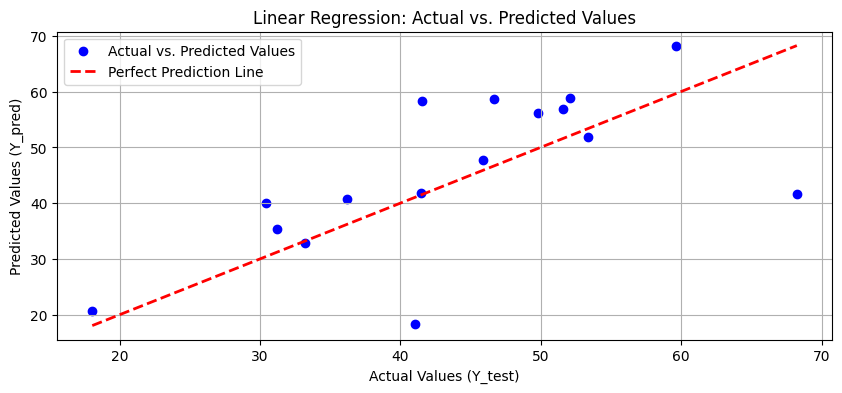

Mean Absolute Error (MAE): 8.13
R-squared (R2): 0.14


In [ ]:
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt

y_pred = model.predict(x_test)
plt.figure(figsize=(10,4))
plt.scatter(y_test, y_pred, color='blue', label='Actual vs. Predicted Values')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--', linewidth=2, label='Perfect Prediction Line')
plt.title('Linear Regression: Actual vs. Predicted Values')
plt.xlabel('Actual Values (Y_test)')
plt.ylabel('Predicted Values (Y_pred)')
plt.legend()
plt.grid(True)
plt.show()

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"R-squared (R2): {r2:.2f}")

In [ ]:
mae=mean_absolute_error(y_test, y_pred)
r2= r2_score(y_test, y_pred)

print(mae, r2)

8.12705419529518 0.14325587622739178


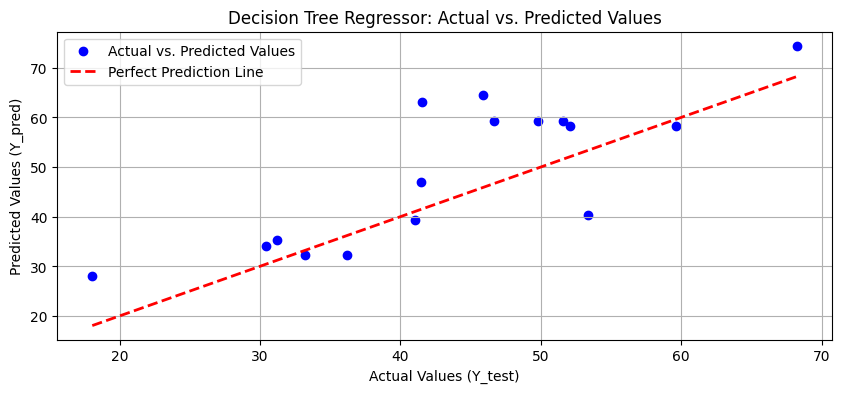

Mean Absolute Error (MAE): 7.92
R-squared (R2): 0.33


In [ ]:
y_pred = model_2.predict(x_test)
plt.figure(figsize=(10,4))
plt.scatter(y_test, y_pred, color='blue', label='Actual vs. Predicted Values')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--', linewidth=2, label='Perfect Prediction Line')
plt.title('Decision Tree Regressor: Actual vs. Predicted Values')
plt.xlabel('Actual Values (Y_test)')
plt.ylabel('Predicted Values (Y_pred)')
plt.legend()
plt.grid(True)
plt.show()
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"R-squared (R2): {r2:.2f}")

In [ ]:
from sklearn.ensemble import RandomForestRegressor

model_3=RandomForestRegressor()
model_3.fit(x_train, y_train)

RandomForestRegressor()

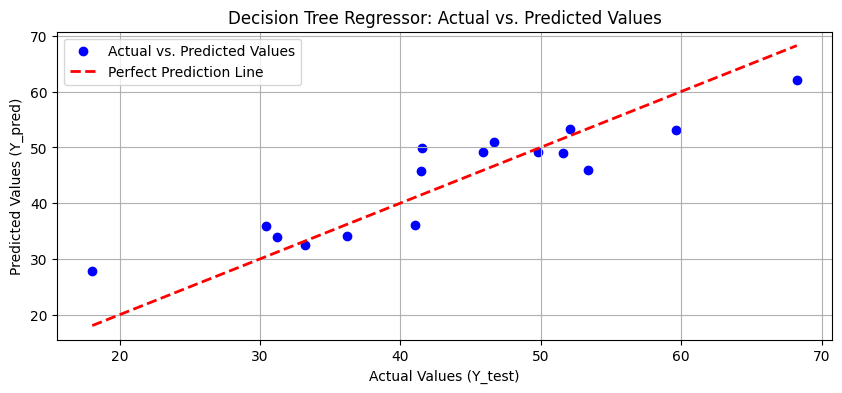

Mean Absolute Error (MAE): 4.39
R-squared (R2): 0.82


In [ ]:

y_pred = model_3.predict(x_test)
plt.figure(figsize=(10,4))
plt.scatter(y_test, y_pred, color='blue', label='Actual vs. Predicted Values')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--', linewidth=2, label='Perfect Prediction Line')
plt.title('Decision Tree Regressor: Actual vs. Predicted Values')
plt.xlabel('Actual Values (Y_test)')
plt.ylabel('Predicted Values (Y_pred)')
plt.legend()
plt.grid(True)
plt.show()
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"R-squared (R2): {r2:.2f}")

In [ ]:
from sklearn.svm import SVR
from sklearn import metrics

svr=SVR(kernel='rbf')
svr.fit(x_train,y_train)
y_predict=svr.predict(x_test)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"R-squared (R2): {r2:.2f}")

Mean Absolute Error (MAE): 4.39
R-squared (R2): 0.82
